# ISYS 574  Homework 1

This homework uses a dataset of individual diamonds, each with a set of physical and quality characteristics along with the price it sold for.

Your goal is to build a linear regression model that predicts a diamond price from the other diamond features. 
<br> You will evaluate your model using RMSE and iterate on it the way we covered in class.

Use this file to write your code; then submit this file on Canvas.
<br> You can add extra cells in each sections, as needed


**Write your name below**

In [1]:
# Name: Antonio Garza Moore Jr.

In [2]:
#Use this cell to import the required libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load & Understand the Data (2 pts)
* Load the Diamond.csv file into a DataFrame. 
* Get an overview: shape, column names, data types


In [4]:
diamond = pd.read_csv('Diamonds.csv')

diamond.head()

,carat,depth,table,x,y,z,cut,color,clarity,price
0,0.33,61.7,55.0,4.43,4.46,2.74,Ideal,H,SI1,564
1,1.20,62.1,57.0,6.78,6.71,4.19,Ideal,I,VS2,5914
2,0.62,61.0,57.0,5.51,5.54,3.37,Ideal,D,VS1,2562
3,0.34,63.1,56.0,4.41,4.46,2.80,Good,H,VS2,537
4,1.20,62.5,55.0,6.77,6.84,4.25,Ideal,E,SI2,5964


In [5]:
diamond.shape

(3000, 10)

In [6]:
diamond.columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity',
       'price'],
      dtype='str')

In [7]:
diamond.dtypes

carat      float64
depth      float64
table      float64
x          float64
y          float64
z          float64
cut            str
color          str
clarity        str
price        int64
dtype: object

In [8]:
diamond.describe(include='all')

,carat,depth,table,x,y,z,cut,color,clarity,price
count,3000.000000,2850.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000,3000,3000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,5,7,8,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Ideal,G,SI1,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1200,635,753,NaN
mean,0.804837,61.793333,57.403433,5.754460,5.755510,3.553240,NaN,NaN,NaN,3966.751000
std,0.464427,1.462607,2.219311,1.102141,1.094363,0.689467,NaN,NaN,NaN,3943.221253
min,0.210000,55.800000,52.000000,3.850000,3.840000,0.000000,NaN,NaN,NaN,339.000000
25%,0.400000,61.000000,56.000000,4.740000,4.750000,2.930000,NaN,NaN,NaN,947.750000
50%,0.710000,61.900000,57.000000,5.720000,5.740000,3.550000,NaN,NaN,NaN,2552.000000
75%,1.050000,62.500000,59.000000,6.560000,6.550000,4.040000,NaN,NaN,NaN,5419.500000


## 2. Data Preparation (2 pts)
* Check the dataset for consistency issues: column naming, spacing, casing


In [9]:
# Remove anything above or after the string
diamond.columns = diamond.columns.str.strip() 

In [10]:
# Convert every letter in the string to a lowercase
diamond.columns = diamond.columns.str.lower()

In [11]:
#Make spaces obvious
diamond.columns = diamond.columns.str.replace(' ', '_')

In [12]:
diamond.columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity',
       'price'],
      dtype='str')

## 3. Exploratory Data Analysis (3 pts)
* Explore each column. Look at the number of unique values in the categorical columns
* Plot a histogram of price, and decide whether a log transform is needed

In [13]:
diamond['cut'].unique()

<ArrowStringArray>
['Ideal', 'Good', 'Premium', 'Very Good', 'Fair']
Length: 5, dtype: str

In [14]:
diamond['color'].unique()

<ArrowStringArray>
['H', 'I', 'D', 'E', 'G', 'F', 'J']
Length: 7, dtype: str

In [15]:
diamond['clarity'].unique()

<ArrowStringArray>
['SI1', 'VS2', 'VS1', 'SI2', 'VVS2', 'IF', 'VVS1', 'I1']
Length: 8, dtype: str

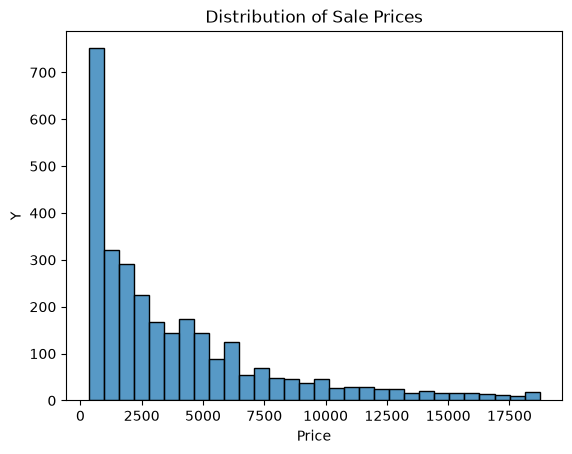

In [16]:
sns.histplot(data = diamond['price'])

plt.ylabel('Y')
plt.xlabel('Price')
plt.title('Distribution of Sale Prices')
plt.show()

The "price" distribution shows a **long tail** and a **right-skewed** distribution due to a few diamonds with high prices
<br>Ideally, we want the distribution to be equally distributed around the median.
<br>Therefore, we will use a **log1** transform

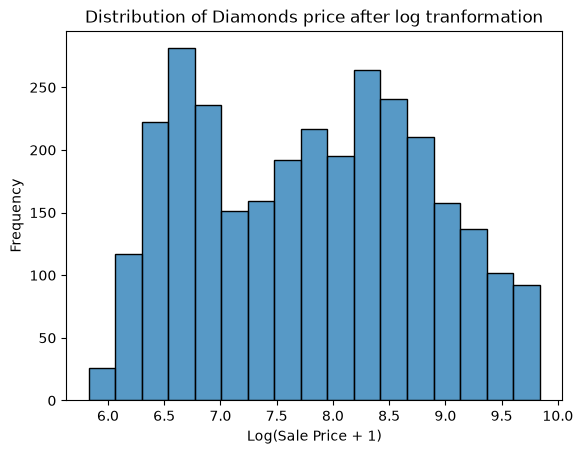

In [17]:
log_price = np.log1p(diamond['price'])
sns.histplot(data = log_price)

plt.ylabel('Frequency')
plt.xlabel('Log(Sale Price + 1)')
plt.title('Distribution of Diamonds price after log tranformation')
plt.show()

## 4. Create Train / Validation / Test Sets (2 pts)
* Shuffle and split the data into a 60% train / 20% validation / 20% test set
* Make sure to separate the target data for each set

In [18]:
# We use a 60%-20%-20%  split and set the length of each set
n = len(diamond)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)
np.random.seed(48)

#we create an array of shuffled consecutive integers
idx = np.arange(n)
np.random.shuffle(idx)

#We create a new dataframe based on the shuffled index
diamond_shuffled = diamond.iloc[idx]

# We create the 3 sets
diamond_train = diamond_shuffled.iloc[:n_train]
diamond_val = diamond_shuffled.iloc[n_train:n_train+n_val]
diamond_test = diamond_shuffled.iloc[n_train+n_val:]

# we can reset the index value to generic ordered values 
diamond_train = diamond_train.reset_index(drop=True)
diamond_val = diamond_val.reset_index(drop=True)
diamond_test = diamond_test.reset_index(drop=True)

In [19]:

y_train = np.log1p(diamond_train['price'].values)
y_val = np.log1p(diamond_val['price'].values)
y_test = np.log1p(diamond_test['price'].values)

#we also remove this target column from the dataset to avoid future miscalculation
del diamond_train['price']
del diamond_val['price']
del diamond_test['price']

In [20]:
print("Train Set has ", diamond_train.shape[0], "rows")
print("Validation Set has ", diamond_val.shape[0], "rows")
print("Test Set has ", diamond_test.shape[0], "rows")

Train Set has  1800 rows
Validation Set has  600 rows
Test Set has  600 rows


## 5. Apply Linear Regression: Numerical Features Only (4 pts)
* Build a prepare_X() function using only the numerical columns. Decide on how to manage possible missing values
* Train your model
* Compute the training RMSE
* Try predicting on the validation set

In [21]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]


def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [22]:
diamond.dtypes

carat      float64
depth      float64
table      float64
x          float64
y          float64
z          float64
cut            str
color          str
clarity        str
price        int64
dtype: object

In [23]:
num_features = ['carat','depth', 'table','x','y','z']

In [24]:
num_features

['carat', 'depth', 'table', 'x', 'y', 'z']

In [25]:
def prepare_X(df):
    #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['carat','depth', 'table','x','y','z']
    features = num_features.copy()

    #we filter the columns used for the model
    df_col = df[features]
    
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [26]:
prepare_X(diamond_train)

array([[ 2.04,   nan, 57.  ,  8.13,  8.08,  5.09],
       [ 0.44, 61.1 , 59.  ,  4.9 ,  4.86,  2.98],
       [ 0.51, 63.2 , 58.  ,  5.08,  5.11,  3.22],
       ...,
       [ 0.36, 62.2 , 59.  ,  4.57,  4.53,  2.83],
       [ 0.39, 61.4 , 57.  ,  4.72,  4.66,  2.88],
       [ 1.15, 63.  , 54.  ,  6.64,  6.73,  4.21]], shape=(1800, 6))

In [27]:
#we prepare the train set
X_train = prepare_X(diamond_train)

#we derive our model weights and bias
w0, w = train_linear_regression(X_train, y_train)

In [28]:
w0

np.float64(nan)

In [29]:
w

array([nan, nan, nan, nan, nan, nan])

In [30]:
# Let's review our missing values
diamond[num_features].isnull().sum()

carat      0
depth    150
table      0
x          0
y          0
z          0
dtype: int64

In [31]:
def prepare_X(df):
    #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['carat','depth', 'table','x','y','z']
    features = num_features.copy()

    # We replace depth missing values with 0
    df['depth'] = df['depth'].fillna(0)


    
    #we filter the columns used for the model
    df_col = df[features]
   
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [32]:
#We retrain the model
#we prepare the train set
X_train = prepare_X(diamond_train)

#we derive our model weights and bias
w0, w = train_linear_regression(X_train, y_train)

print("bias:", w0)
print("weights:", w)

bias: 1.4136274553652037
weights: [-1.02669607e+00  1.22341043e-04 -6.16865021e-03  2.90651927e-01
  8.46206813e-01  2.89512129e-01]


In [33]:
# we get the predicted sale price of the train set
y_train_pred = w0 + X_train.dot(w)

#We compute the RMSE for the training set
print('train RMSE:' , rmse(y_train, y_train_pred) )

train RMSE: 0.2563610698473413


In [34]:
# We re-prepare the validation set
X_val = prepare_X(diamond_val)

# we get the predicted sale price of the validation set
y_val_pred = w0 + X_val.dot(w)

#We compute the RMSE for the validation set
print('validation RMSE:' , rmse(y_val, y_val_pred) )

validation RMSE: 0.28602946279947666


In [35]:
#Let's save those values in a dictionnary for future comparison
results = {}

results['baseline_numerical'] = {'train_rmse': 0.256, 'val_rmse': 0.286}

In [36]:
#We can also create a run_model function to re-use the model training and RMSE math

def run_model():
    #We run the model
    X_train = prepare_X(diamond_train)
    w0, w = train_linear_regression(X_train, y_train)
    
    # we get the predicted sale price of the train set
    y_train_pred = w0 + X_train.dot(w)
    #We compute the RMSE for the training set
    print('train RMSE:' , rmse(y_train, y_train_pred) )
 

    # validation set
    X_val = prepare_X(diamond_val)
    y_val_pred = w0 + X_val.dot(w)
    print('validation RMSE:' , rmse(y_val, y_val_pred) )

    #we return the vias and weight of the model
    return(w0, w)

## 6. Feature Engineering 1 (3 pts)
* Consider whether any existing columns could be transformed into something more useful: Hint: volume = length x width x depth
  
* Update prepare_X() and re-evaluate

In [37]:
def prepare_X(df):
     #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['carat','depth', 'table']
    features = num_features.copy()

    # We replace depth missing values with 0
    df['depth'] = df['depth'].fillna(0)

    # We create the Volume feature
    df['Volume'] = df['x'] * df ['y'] * df ['z'] 
    # and add it to list of features column used for the model
    features.append('Volume')

    
    #we filter the columns used for the model
    df_col = df[features]  
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [38]:
run_model()

train RMSE: 0.3889584457269716
validation RMSE: 0.40616337707216105


(np.float64(6.050249963017221),
 array([ 5.41609891e-01, -1.61215805e-04,  2.38026171e-03,  9.12695403e-03]))

In [39]:
#Let's save those values in our dictionnary
results['Volume Feature'] = {'train_rmse': 0.388, 'val_rmse': 0.406}

## 7. Feature Engineering 2: Categorical Variables (4 pts)
* Assess your categorical columns
* One-hot encode your categorical columns. Don't forget to have a reference value to exclude
* Update prepare_X() and re-evaluate

In [40]:
diamond.head()

,carat,depth,table,x,y,z,cut,color,clarity,price
0,0.33,61.7,55.0,4.43,4.46,2.74,Ideal,H,SI1,564
1,1.20,62.1,57.0,6.78,6.71,4.19,Ideal,I,VS2,5914
2,0.62,61.0,57.0,5.51,5.54,3.37,Ideal,D,VS1,2562
3,0.34,63.1,56.0,4.41,4.46,2.80,Good,H,VS2,537
4,1.20,62.5,55.0,6.77,6.84,4.25,Ideal,E,SI2,5964


In [41]:
categorical_col = ['cut', 'color', 'clarity']

for col in diamond[categorical_col]:
    print(col)
    print(diamond[col].nunique()) #how many unique values
    print(diamond[col].unique())   
    print()

cut
5
<ArrowStringArray>
['Ideal', 'Good', 'Premium', 'Very Good', 'Fair']
Length: 5, dtype: str

color
7
<ArrowStringArray>
['H', 'I', 'D', 'E', 'G', 'F', 'J']
Length: 7, dtype: str

clarity
8
<ArrowStringArray>
['SI1', 'VS2', 'VS1', 'SI2', 'VVS2', 'IF', 'VVS1', 'I1']
Length: 8, dtype: str



In [42]:
# Let's review our missing values
diamond.isnull().sum()

carat        0
depth      150
table        0
x            0
y            0
z            0
cut          0
color        0
clarity      0
price        0
dtype: int64

In [76]:
def prepare_X(df):
    #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['carat','depth', 'table']
    features = num_features.copy()

    # We replace depth missing values with 0
    df['depth'] = df['depth'].fillna(0)

    # We create the Volume feature
    df['Volume'] = df['x'] * df ['y'] * df ['z'] 
    # and add it to list of features column used for the model
    features.append('Volume')
    #We replace depth missing values with None
    df['depth'] = df['depth'].fillna("None")


    #For the categorical features, we use the first value as reference value
    categorical_col = ['cut', 'color', 'clarity']
    for c in categorical_col:
        values_list = diamond_train[c].unique()    
        for v in values_list[1:] :    #we skip the first value
            feature = '%s_%s' % (c,v)
            values = (df[c] == v).astype(int)                   
            df[feature] = values
            features.append(feature)
    
    #we filter the columns used for the model
    df_col = df[features]  
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [77]:
run_model()

train RMSE: 0.32772535703856637
validation RMSE: 0.322188128124228


(np.float64(5.095209810648678),
 array([ 1.20939312e+00,  9.72920975e-05,  9.94821471e-03,  6.36034819e-03,
        -1.70042391e-02,  5.17381670e-02,  2.26662628e-02, -7.05392159e-03,
         1.00422886e-01,  2.03096128e-01,  2.24799143e-01, -2.67950604e-01,
         1.71358023e-01, -2.81102154e-01,  1.79765208e-01,  4.45128351e-01,
         5.25389044e-01,  2.85028038e-01,  3.35648073e-01, -5.28001241e-01,
         3.63599085e-01]))

In [51]:
#Let's save those values in our dictionnary
results['numerical + volume + categorical'] = {'train_rmse': 0.327, 'val_rmse': 0.322}

In [ ]:
def prepare_X(df):
    #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['carat','depth']
    features = num_features.copy()

    # We replace depth missing values with 0
    df['depth'] = df['depth'].fillna(0)

    # We create the Volume feature
    df['Volume'] = df['x'] * df ['y'] * df ['z'] 
    # and add it to list of features column used for the model
    features.append('Volume')
    #We replace depth missing values with None
    df['depth'] = df['depth'].fillna("None")


    #For the categorical features, we use the first value as reference value
    categorical_col = ['cut', 'color', 'clarity']
    for c in categorical_col:
        values_list = diamond_train[c].unique()    
        for v in values_list[1:] :    #we skip the first value
            feature = '%s_%s' % (c,v)
            values = (df[c] == v).astype(int)                   
            df[feature] = values
            features.append(feature)
    
    #we filter the columns used for the model
    df_col = df[features]  
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [62]:
run_model()

train RMSE: 0.32772535703856637
validation RMSE: 0.322188128124228


(np.float64(5.095209810648678),
 array([ 1.20939312e+00,  9.72920975e-05,  9.94821471e-03,  6.36034819e-03,
        -1.70042391e-02,  5.17381670e-02,  2.26662628e-02, -7.05392159e-03,
         1.00422886e-01,  2.03096128e-01,  2.24799143e-01, -2.67950604e-01,
         1.71358023e-01, -2.81102154e-01,  1.79765208e-01,  4.45128351e-01,
         5.25389044e-01,  2.85028038e-01,  3.35648073e-01, -5.28001241e-01,
         3.63599085e-01]))

In [63]:
def prepare_X(df):
    #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['carat','table']
    features = num_features.copy()

    # We replace depth missing values with 0
    df['depth'] = df['depth'].fillna(0)

    # We create the Volume feature
    df['Volume'] = df['x'] * df ['y'] * df ['z'] 
    # and add it to list of features column used for the model
    features.append('Volume')
    #We replace depth missing values with None
    df['depth'] = df['depth'].fillna("None")


    #For the categorical features, we use the first value as reference value
    categorical_col = ['cut', 'color', 'clarity']
    for c in categorical_col:
        values_list = diamond_train[c].unique()    
        for v in values_list[1:] :    #we skip the first value
            feature = '%s_%s' % (c,v)
            values = (df[c] == v).astype(int)                   
            df[feature] = values
            features.append(feature)
    
    #we filter the columns used for the model
    df_col = df[features]  
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [64]:
run_model()

train RMSE: 0.3277279716692434
validation RMSE: 0.3222616845463748


(np.float64(5.102555953461307),
 array([ 1.21078645,  0.0099161 ,  0.00635169, -0.01678175,  0.05177323,
         0.0227583 , -0.00666897,  0.10040489,  0.20300608,  0.2247915 ,
        -0.26784533,  0.17141173, -0.28108965,  0.1800153 ,  0.4453662 ,
         0.52541529,  0.28520325,  0.33581141, -0.5277278 ,  0.36363723]))

In [65]:
def prepare_X(df):
    #For safety purpose, we create a copy of the received datframe
    df = df.copy()
    #and a copy of the numerical features
    num_features = ['depth','table']
    features = num_features.copy()

    # We replace depth missing values with 0
    df['depth'] = df['depth'].fillna(0)

    # We create the Volume feature
    df['Volume'] = df['x'] * df ['y'] * df ['z'] 
    # and add it to list of features column used for the model
    features.append('Volume')
    #We replace depth missing values with None
    df['depth'] = df['depth'].fillna("None")


    #For the categorical features, we use the first value as reference value
    categorical_col = ['cut', 'color', 'clarity']
    for c in categorical_col:
        values_list = diamond_train[c].unique()    
        for v in values_list[1:] :    #we skip the first value
            feature = '%s_%s' % (c,v)
            values = (df[c] == v).astype(int)                   
            df[feature] = values
            features.append(feature)
    
    #we filter the columns used for the model
    df_col = df[features]  
    # we create a matrix (2D array) with only the values
    X = df_col.values
    #we return the matrix
    return X

In [66]:
run_model()

train RMSE: 0.3299972686340583
validation RMSE: 0.325497126538848


(np.float64(4.98258368386353),
 array([ 1.95025747e-04,  1.18882280e-02,  1.38261448e-02, -1.00257464e-02,
         4.47148833e-02,  2.12882602e-02,  2.96496118e-02,  1.05634614e-01,
         2.00967697e-01,  2.23096845e-01, -2.67590811e-01,  1.70204337e-01,
        -2.82927727e-01,  1.74491083e-01,  4.36601249e-01,  5.13451535e-01,
         2.79342794e-01,  3.25445399e-01, -5.14629015e-01,  3.53178846e-01]))

## 8. Evaluate & Iterate (3 pts)
* Compare your validation RMSE across every version of your model so far (numerical-only, after missing values, after feature engineering, after categorical encoding).


In [67]:
pd.DataFrame(results)

,baseline_numerical,Volume Feature,numerical + volume + categorical
train_rmse,0.256,0.388,0.327
val_rmse,0.286,0.406,0.322


## 9. Final Model on the Test Set (2 pts)
* Once you're satisfied with your model based on validation performance, run it once on the test set and report the test RMSE.
* Pick a few random diamonds from the test set and compare predicted vs. actual price.

In [68]:
#Let's see the performance with our test set
X_train = prepare_X(diamond_train)
w0, w = train_linear_regression(X_train, y_train)

X_test = prepare_X(diamond_test)
# we get the predicted msrp of the validation set
y_test_pred = w0 + X_test.dot(w)
#We compute the RMSE of the validation set
print('test RMSE:' , rmse(y_test, y_test_pred) )

test RMSE: 0.34201048035433385


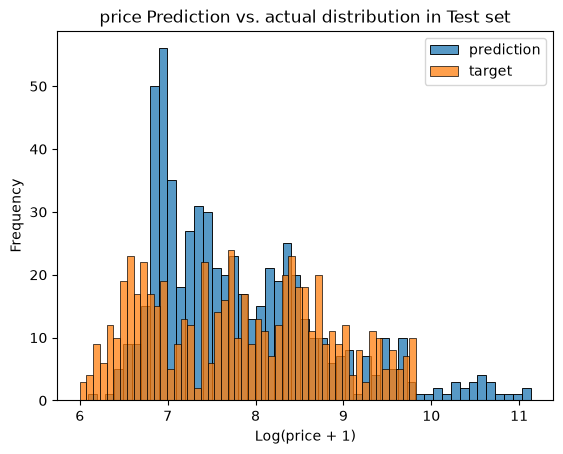

In [69]:
#Let's see the distribution of the target value
fig, ax = plt.subplots()
    
sns.histplot(data = y_test_pred, bins = 50, ax = ax, label= 'prediction')
sns.histplot(data = y_test, bins = 50, ax = ax, label= 'target')

plt.ylabel('Frequency')
plt.xlabel('Log(price + 1)')
plt.title('price Prediction vs. actual distribution in Test set')
plt.legend()
plt.show()

In [70]:
### Let's pick a set of house from the test set

import random
# We get 5 random position from the set
pos = [ random.randint(0,diamond_test.shape[0]-1)   for x in range(5) ]

print(pos)

[387, 589, 56, 109, 28]


In [71]:
df_rand_diamond = diamond_test.iloc[pos]
df_rand_diamond

,carat,depth,table,x,y,z,cut,color,clarity
387,1.52,62.9,60.0,7.28,7.31,4.59,Very Good,G,VS2
589,2.37,62.3,57.0,8.55,8.50,5.31,Premium,H,SI2
56,1.02,57.4,59.0,6.64,6.60,3.80,Good,G,I1
109,0.28,61.1,60.0,4.21,4.17,2.56,Premium,E,VVS1
28,0.70,61.8,56.0,5.70,5.76,3.54,Very Good,G,SI1


In [72]:
#We create the feature matrix
X_rand_diamond = prepare_X(df_rand_diamond)

#We get the price prediction
y_rand_pred = w0 + X_rand_diamond.dot(w)
y_rand_pred

array([ 9.49165495, 11.00793081,  7.57864795,  6.96674517,  7.56873855])

In [73]:
#Let's not forget the target computed is the logarithm of the price - 1

#Actualy predicted prices
#expm1 for Exponential - 1
np.expm1(y_rand_pred)

array([13247.70315796, 60349.88009888,  1954.98258222,  1059.76451489,
        1935.69568995])

In [74]:
# the actual selling price
Y_rand_diamond = y_test[pos]
np.expm1(Y_rand_diamond )

array([12038., 16021.,  2344.,   828.,  2106.])

In [75]:
diamond_pred = pd.DataFrame( index = df_rand_diamond.index, 
                          data = {
                            'Predicted Price': np.expm1(y_rand_pred)
                            ,'Actual Price': np.expm1(Y_rand_diamond )} )
diamond_pred     

,Predicted Price,Actual Price
387,13247.703158,12038.0
589,60349.880099,16021.0
56,1954.982582,2344.0
109,1059.764515,828.0
28,1935.695690,2106.0
